In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
from sklearn.datasets import make_regression

In [34]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=50,random_state=13)

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
LR=LinearRegression()

In [39]:
LR.fit(x,y)

LinearRegression()

In [40]:
y_pred=LR.predict(x_test)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [42]:
print(mean_squared_error(y_test,y_pred))

2112.190964421295


In [43]:
print(mean_absolute_error(y_test,y_pred))

38.243817597944194


In [44]:
LR.intercept_

-5.736861396692448

In [45]:
LR.coef_

array([28.15776483])

In [65]:
class MeraLR:
    def __init__(self,Learning_rate,epochs,m,b):
        self.m=m
        self.b=b
        self.Learning_rate=Learning_rate
        self.epochs=epochs
    
    def fit(self,x,y):
        for i in range(self.epochs):
            loss_rate_m=-2*np.sum((y-self.m*x.ravel()-self.b)*x.ravel())
            loss_rate_b=-2*np.sum(y-self.m*x.ravel()-self.b)
            self.m=self.m-loss_rate_m*self.Learning_rate
            self.b=self.b-loss_rate_b*self.Learning_rate
    def pred(self,x):
        return self.m*x + self.b

In [84]:
lr=MeraLR(0.0001,1000,500,-112)

In [85]:
lr.fit(x,y)

In [86]:
y_pred=lr.pred(x)

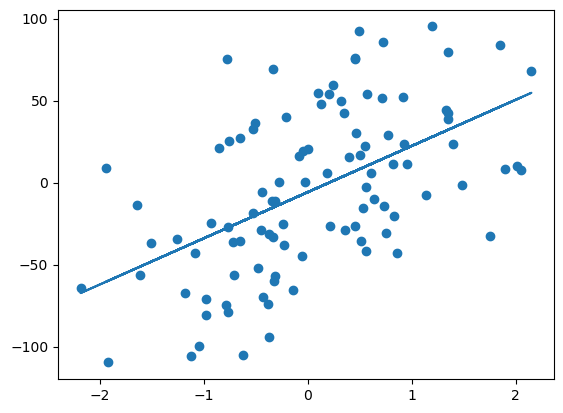

In [87]:
plt.plot(x,y_pred)
plt.scatter(x,y)

In [88]:
lr.m

28.15778106791693

In [89]:
lr.b

-5.736867604410655

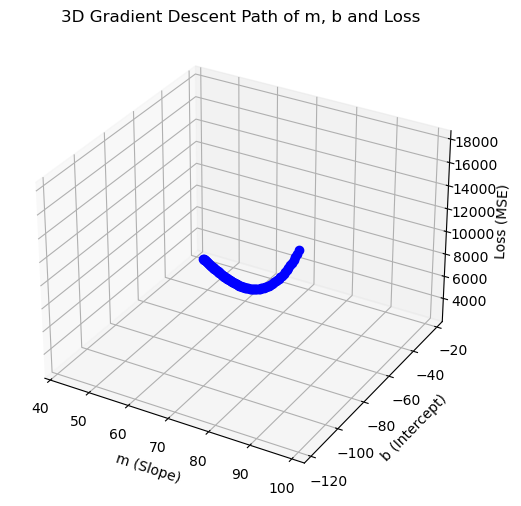

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

epochs = 100
learn_rate = 0.0001
m = 100
b = -120
list_m = []
list_b = []
loss_values = []

for i in range(epochs):
    y_pred = m * x.ravel() + b
    loss = np.mean((y - y_pred)**2)
    loss_values.append(loss)
    
    
    loss_rate_m = -2 * np.sum((y - y_pred) * x.ravel())
    loss_rate_b = -2 * np.sum(y - y_pred)
    
    m = m - learn_rate * loss_rate_m
    b = b - learn_rate * loss_rate_b
    
    list_m.append(m)
    list_b.append(b)

list_m = np.array(list_m)
list_b = np.array(list_b)
loss_values = np.array(loss_values)


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(list_m, list_b, loss_values, color='blue', marker='o', linewidth=1)

ax.set_xlabel('m (Slope)')
ax.set_ylabel('b (Intercept)')
ax.set_zlabel('Loss (MSE)')
ax.set_title('3D Gradient Descent Path of m, b and Loss')
plt.show()
